# **Taller Final - Pronóstico de Ventas de Productos** #

### Alexander Torres Viveros ###
*alexandertorresviveros@gmail.com*

---

## **El Problema**

Una compañía de comestibles está interesada en predecir el comportamiento de las ventas (en unidades) de sus dos productos estrella. Fuimos contratados para generar un modelo que permita pronosticar las ventas del siguiente mes de cada uno de esos dos productos. La base de datos disponible en el archivo `Examen.csv` tiene la información de cada uno de los productos desde junio de 2014.

---

## 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN

In [3]:
# Importar módulo de configuración personalizado
import config_graficos as cfg
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Configurar entorno de trabajo
cfg.configurar_entorno()

print("Librerías importadas y configuración completada")

Entorno configurado correctamente
Fecha de análisis: 2025-12-03 17:40
Librerías importadas y configuración completada


## 2. CARGA DE DATOS

In [4]:
# Cargar datos desde archivo CSV
data = pd.read_csv("Examen.csv")

# Información básica del dataset
print(f"Forma del dataset: {data.shape}")
print(f"Columnas: {list(data.columns)}")
    


Forma del dataset: (127, 3)
Columnas: ['Unnamed: 0', 'producto1', 'producto2']


In [5]:
# Mostrar primeras filas
print("PRIMERAS 10 FILAS DEL DATASET:")
print("=" * 50)
display(data.head(10))

print("\nÚLTIMAS 5 FILAS DEL DATASET:")
print("=" * 50)
display(data.tail())

PRIMERAS 10 FILAS DEL DATASET:


,Unnamed: 0,producto1,producto2
0,1,500.000000,200.000000
1,2,497.400893,210.686220
2,3,478.605317,222.018584
3,4,486.454125,233.920990
4,5,479.695678,238.402098
5,6,474.222492,247.623815
6,7,484.103665,249.901717
7,8,481.695269,261.832340
8,9,476.705402,277.360465
9,10,468.330510,286.418917



ÚLTIMAS 5 FILAS DEL DATASET:


,Unnamed: 0,producto1,producto2
122,123,164.610771,629.293034
123,124,150.881839,637.099467
124,125,151.788470,653.155282
125,126,137.047639,672.528345
126,127,141.990873,676.058092


## 3. EXPLORACIÓN BÁSICA

In [6]:
# Información detallada del dataset
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
data.info()

print("\nESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)
display(data.describe())

# Verificar valores faltantes
print("\nVALORES FALTANTES:")
print("=" * 50)
missing = data.isnull().sum()
if missing.sum() == 0:
    print("No hay valores faltantes")
else:
    print(missing[missing > 0])

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127 entries, 0 to 126
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  127 non-null    int64  
 1   producto1   127 non-null    float64
 2   producto2   127 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 3.1 KB

ESTADÍSTICAS DESCRIPTIVAS


,Unnamed: 0,producto1,producto2
count,127.000000,127.000000,127.000000
mean,64.000000,343.571660,581.037664
std,36.805797,100.234821,167.504363
min,1.000000,137.047639,200.000000
25%,32.500000,256.853812,469.194001
50%,64.000000,340.644019,626.048401
75%,95.500000,450.071775,708.941718
max,127.000000,500.000000,806.440615



VALORES FALTANTES:
No hay valores faltantes


In [7]:
# Análisis específico de cada producto
print("ANÁLISIS ESPECÍFICO POR PRODUCTO")
print("=" * 50)

for col in data.columns:
    if col.startswith('producto'):
        print(f"\n{col.upper()}:")
        print(f"  • Mínimo: {data[col].min():.2f}")
        print(f"  • Máximo: {data[col].max():.2f}")
        print(f"  • Media: {data[col].mean():.2f}")
        print(f"  • Mediana: {data[col].median():.2f}")
        print(f"  • Desv. Estándar: {data[col].std():.2f}")
        print(f"  • CV: {(data[col].std()/data[col].mean())*100:.2f}%")

ANÁLISIS ESPECÍFICO POR PRODUCTO

PRODUCTO1:
  • Mínimo: 137.05
  • Máximo: 500.00
  • Media: 343.57
  • Mediana: 340.64
  • Desv. Estándar: 100.23
  • CV: 29.17%

PRODUCTO2:
  • Mínimo: 200.00
  • Máximo: 806.44
  • Media: 581.04
  • Mediana: 626.05
  • Desv. Estándar: 167.50
  • CV: 28.83%


## **4. VISUALIZACIONES EXPLORATORIAS**

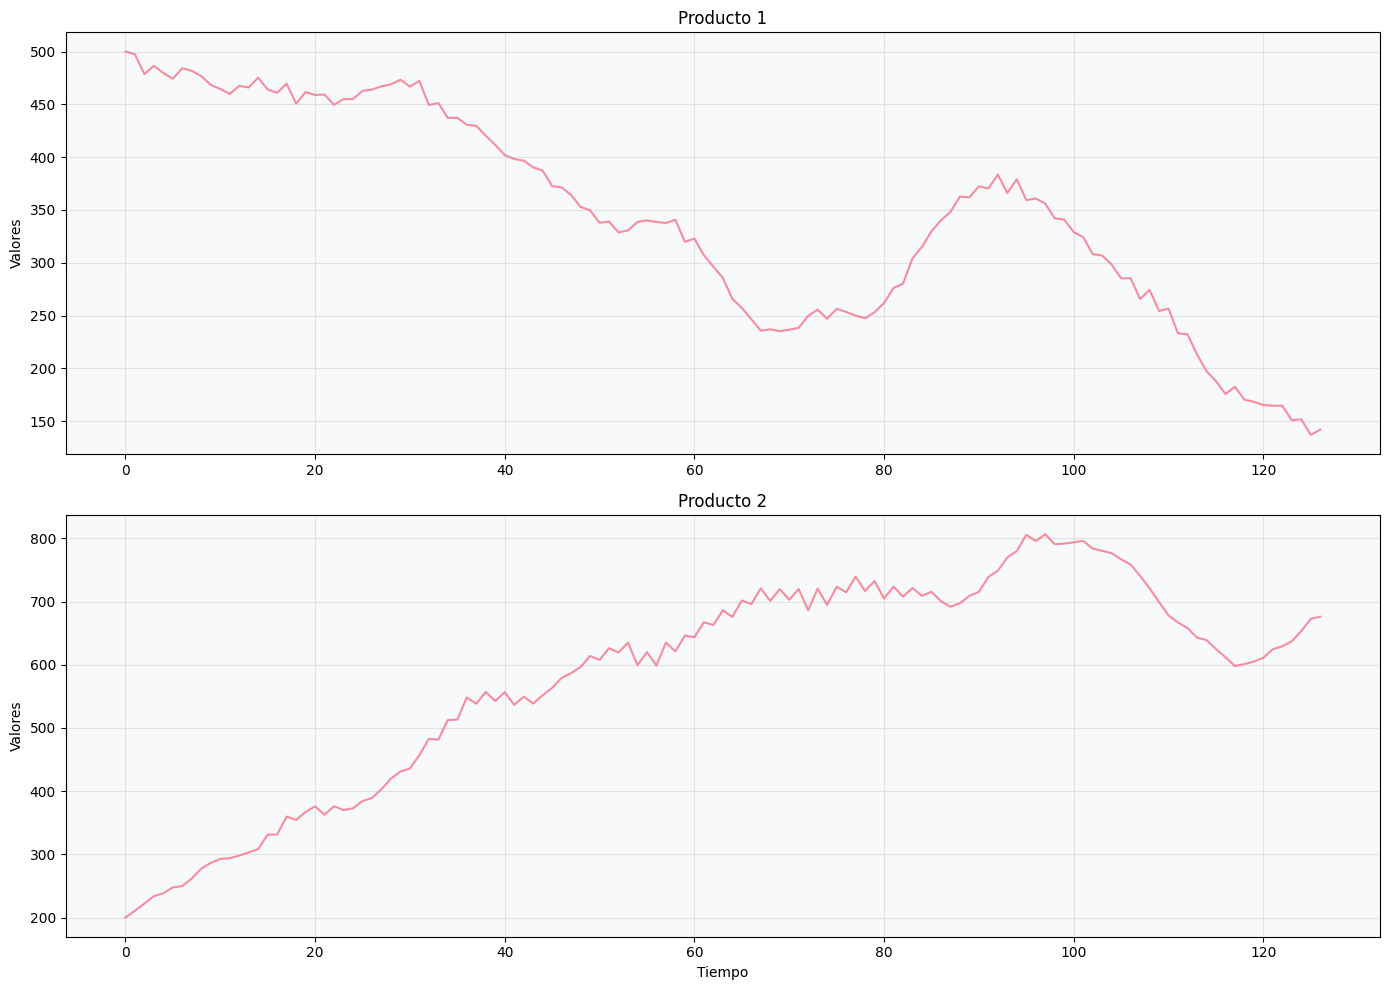

Producto 1: Rango [137.0, 500.0]
Producto 2: Rango [200.0, 806.4]


In [17]:
# Gráfico de series de tiempo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Producto 1
ax1.plot(data.index, data['producto1'],alpha=0.8)
ax1.set_title('Producto 1')
ax1.set_ylabel('Valores')
ax1.grid(True, alpha=0.3)


# Producto 2
ax2.plot(data.index, data['producto2'], alpha=0.8)
ax2.set_title('Producto 2')
ax2.set_ylabel('Valores')
ax2.set_xlabel('Tiempo')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de los gráficos
print(f"Producto 1: Rango [{data['producto1'].min():.1f}, {data['producto1'].max():.1f}]")
print(f"Producto 2: Rango [{data['producto2'].min():.1f}, {data['producto2'].max():.1f}]")

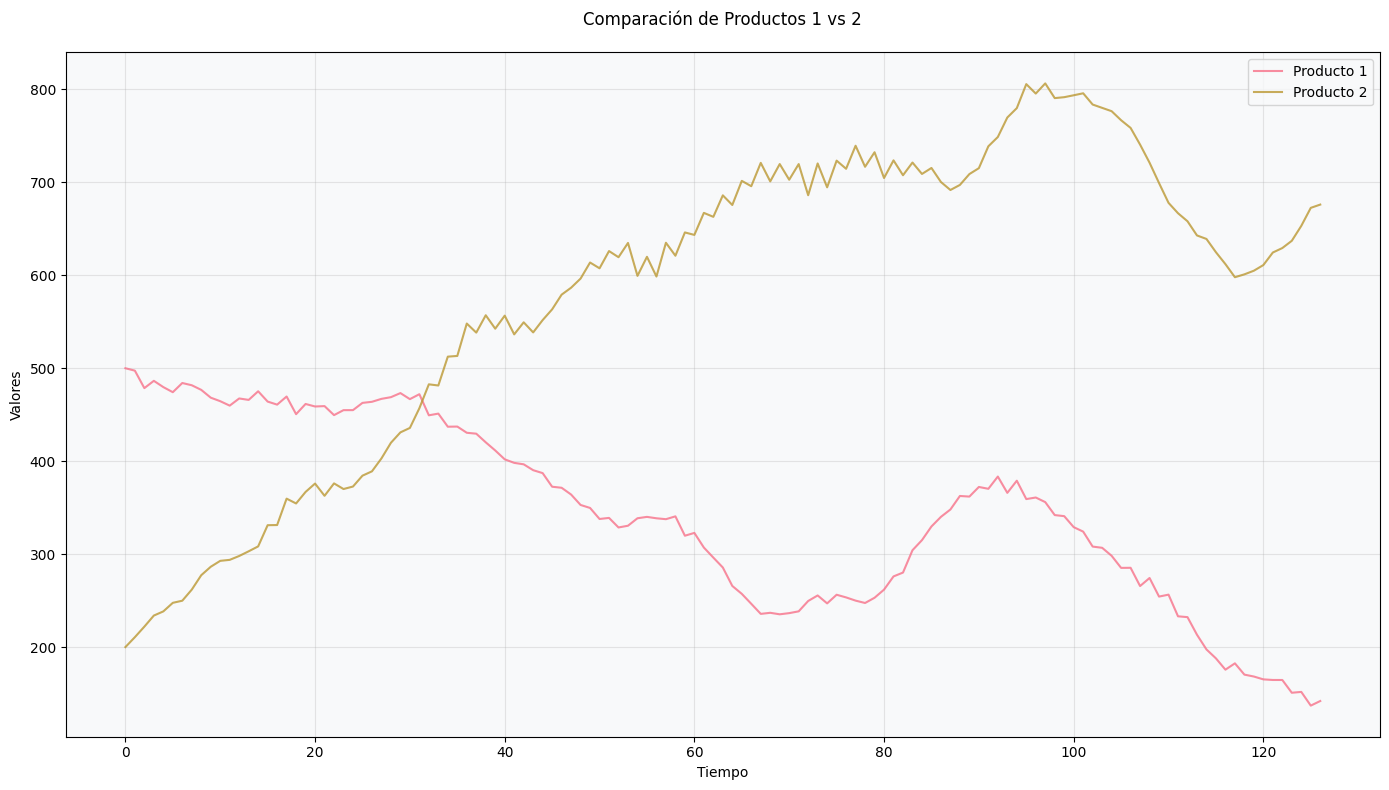

In [19]:
# Comparación de ambos productos en un solo gráfico
plt.figure(figsize=(14, 8))

plt.plot(data.index, data['producto1'], label='Producto 1',alpha=0.8)
plt.plot(data.index, data['producto2'], label='Producto 2',alpha=0.8)

plt.title('Comparación de Productos 1 vs 2', pad=20)
plt.xlabel('Tiempo')
plt.ylabel('Valores')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

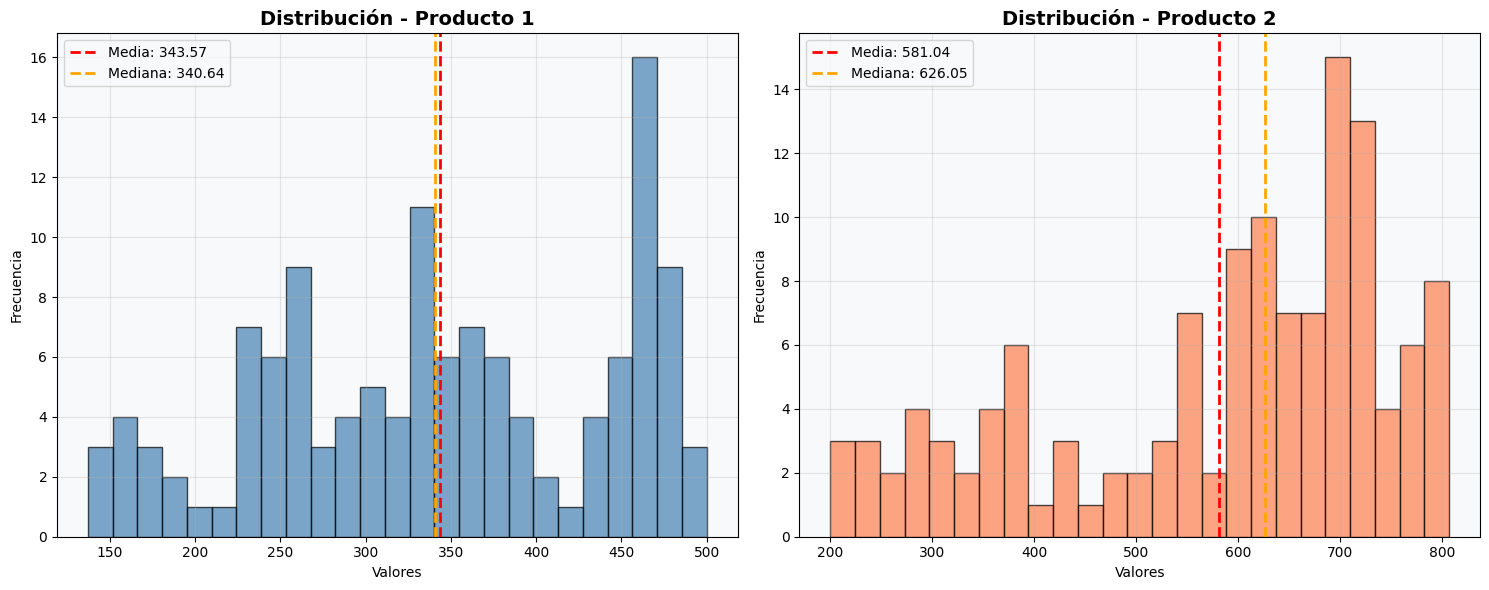

In [10]:
# Histogramas de distribución
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histograma Producto 1
ax1.hist(data['producto1'], bins=25, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(data['producto1'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data["producto1"].mean():.2f}')
ax1.axvline(data['producto1'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {data["producto1"].median():.2f}')
ax1.set_title('Distribución - Producto 1', fontsize=14, fontweight='bold')
ax1.set_xlabel('Valores')
ax1.set_ylabel('Frecuencia')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histograma Producto 2
ax2.hist(data['producto2'], bins=25, color='coral', alpha=0.7, edgecolor='black')
ax2.axvline(data['producto2'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data["producto2"].mean():.2f}')
ax2.axvline(data['producto2'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {data["producto2"].median():.2f}')
ax2.set_title('Distribución - Producto 2', fontsize=14, fontweight='bold')
ax2.set_xlabel('Valores')
ax2.set_ylabel('Frecuencia')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

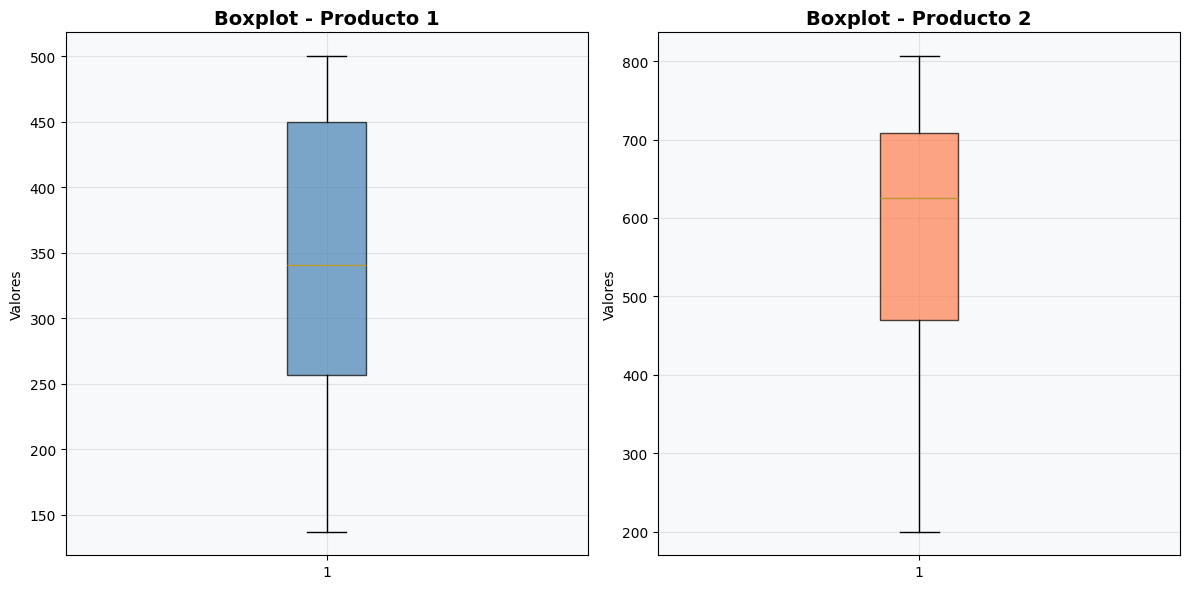

Producto 1:
   • Q1: 256.85, Q3: 450.07, IQR: 193.22
   • Límites: [-32.97, 739.90]
   • Outliers detectados: 0

Producto 2:
   • Q1: 469.19, Q3: 708.94, IQR: 239.75
   • Límites: [109.57, 1068.56]
   • Outliers detectados: 0



In [11]:
# Boxplots para detectar outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Boxplot Producto 1
box1 = ax1.boxplot(data['producto1'], patch_artist=True)
box1['boxes'][0].set_facecolor('steelblue')
box1['boxes'][0].set_alpha(0.7)
ax1.set_title('Boxplot - Producto 1', fontsize=14, fontweight='bold')
ax1.set_ylabel('Valores')
ax1.grid(True, alpha=0.3)

# Boxplot Producto 2
box2 = ax2.boxplot(data['producto2'], patch_artist=True)
box2['boxes'][0].set_facecolor('coral')
box2['boxes'][0].set_alpha(0.7)
ax2.set_title('Boxplot - Producto 2', fontsize=14, fontweight='bold')
ax2.set_ylabel('Valores')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detectar outliers usando IQR
def detect_outliers(serie, name):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    
    print(f"{name}:")
    print(f"   • Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"   • Límites: [{lower:.2f}, {upper:.2f}]")
    print(f"   • Outliers detectados: {len(outliers)}")
    if len(outliers) > 0:
        print(f"   • Valores outliers: {outliers.values}")
    print()

detect_outliers(data['producto1'], 'Producto 1')
detect_outliers(data['producto2'], 'Producto 2')

## 5. ANÁLISIS DE CORRELACIÓN

<Figure size 800x600 with 0 Axes>

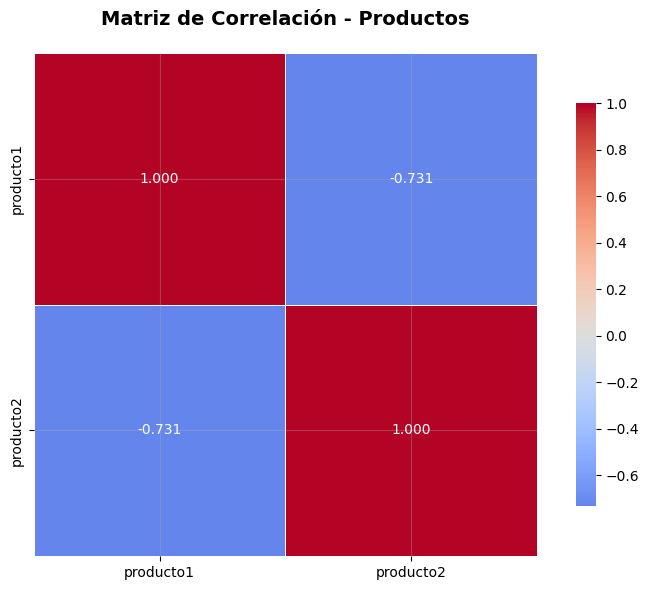

Correlación entre productos: -0.7307
Interpretación: Correlación fuerte negativa


In [12]:
# Matriz de correlación
correlation_matrix = data[['producto1', 'producto2']].corr()

plt.figure(figsize=(8, 6))
cfg.plot_correlation_matrix(correlation_matrix, title='Matriz de Correlación - Productos')

# Interpretación de la correlación
corr_value = correlation_matrix.loc['producto1', 'producto2']
print(f"Correlación entre productos: {corr_value:.4f}")

if abs(corr_value) < 0.3:
    interpretation = "débil"
elif abs(corr_value) < 0.7:
    interpretation = "moderada"
else:
    interpretation = "fuerte"

direction = "positiva" if corr_value > 0 else "negativa"
print(f"Interpretación: Correlación {interpretation} {direction}")

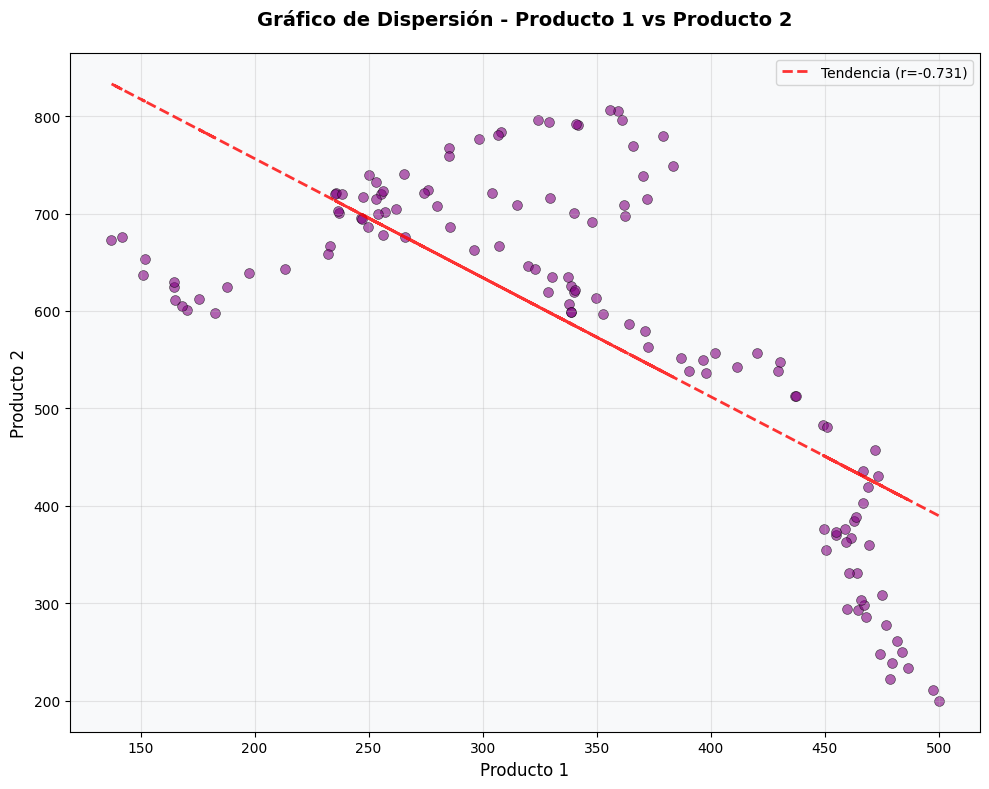

In [13]:
# Gráfico de dispersión
plt.figure(figsize=(10, 8))

plt.scatter(data['producto1'], data['producto2'], alpha=0.6, s=50, color='purple', edgecolors='black', linewidth=0.5)

# Línea de tendencia
z = np.polyfit(data['producto1'], data['producto2'], 1)
p = np.poly1d(z)
plt.plot(data['producto1'], p(data['producto1']), "r--", alpha=0.8, linewidth=2, label=f'Tendencia (r={corr_value:.3f})')

plt.xlabel('Producto 1', fontsize=12)
plt.ylabel('Producto 2', fontsize=12)
plt.title('Gráfico de Dispersión - Producto 1 vs Producto 2', fontsize=14, fontweight='bold', pad=20)
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

## 6. DIVISIÓN TRAIN/TEST

CONFIGURACIÓN DE DIVISIÓN TEMPORAL
Total de observaciones: 127
Entrenamiento: 101 observaciones (79.5%)
Prueba: 26 observaciones (20.5%)

Conjuntos creados:
   • train_to1: (101, 1)
   • train_to2: (101, 1)
   • test_t1: (26, 1)
   • test_to2: (26, 1)


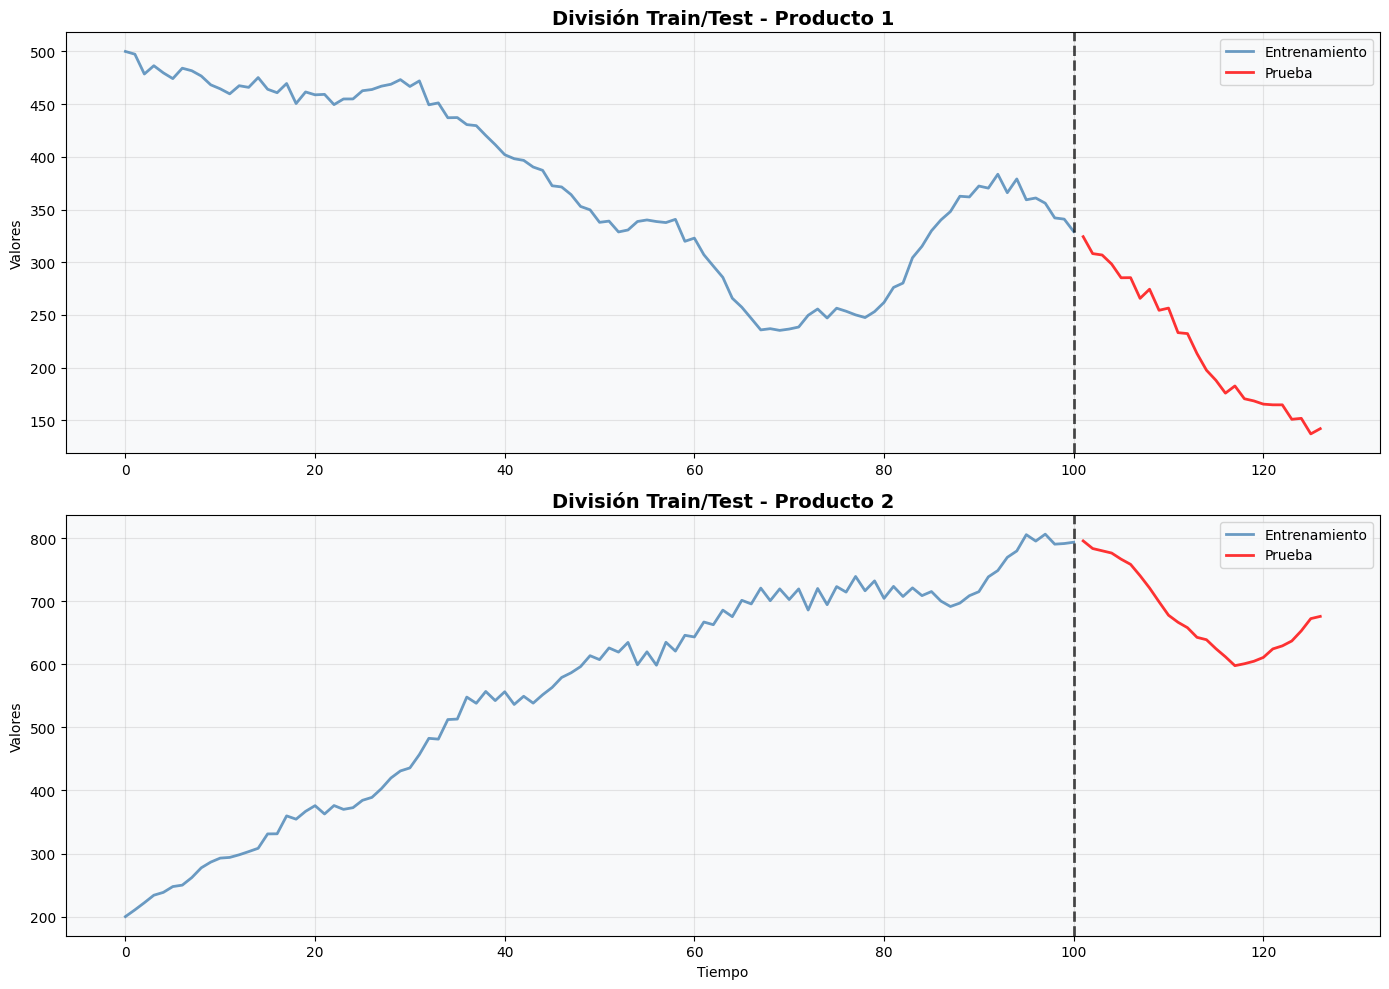

In [14]:
# Configurar división temporal
train_len = int(len(data) * 0.8)  # 80% para entrenamiento
print(f"CONFIGURACIÓN DE DIVISIÓN TEMPORAL")
print("=" * 50)
print(f"Total de observaciones: {len(data)}")
print(f"Entrenamiento: {train_len} observaciones ({train_len/len(data)*100:.1f}%)")
print(f"Prueba: {len(data) - train_len} observaciones ({(len(data) - train_len)/len(data)*100:.1f}%)")

# Crear conjuntos de entrenamiento y prueba
train_to1 = data.iloc[:train_len][['producto1']].copy()
train_to2 = data.iloc[:train_len][['producto2']].copy()
test_t1 = data.iloc[train_len:][['producto1']].copy()
test_to2 = data.iloc[train_len:][['producto2']].copy()

print(f"\nConjuntos creados:")
print(f"   • train_to1: {train_to1.shape}")
print(f"   • train_to2: {train_to2.shape}")
print(f"   • test_t1: {test_t1.shape}")
print(f"   • test_to2: {test_to2.shape}")

# Visualizar la división usando la función del módulo de configuración
cfg.plot_train_test_split(train_to1, test_t1, train_to2, test_to2, train_len, 'División Train/Test')

## 7. GUARDAR DATOS PREPARADOS

In [15]:
# Guardar conjuntos de datos para uso en otros notebooks
datasets = {
    'data': data,
    'train_to1': train_to1,
    'train_to2': train_to2,
    'test_t1': test_t1,
    'test_to2': test_to2,
    'train_len': train_len
}

# Usar función del módulo de configuración para guardar datos
cfg.save_datasets(datasets, 'datasets_preparados.pkl')

print("DATOS GUARDADOS EXITOSAMENTE")
print("=" * 50)
print("Archivo: datasets_preparados.pkl")
print("\nContenido guardado:")
for key, value in datasets.items():
    if hasattr(value, 'shape'):
        print(f"   • {key}: {value.shape}")
    else:
        print(f"   • {key}: {value}")

print("\nLos datos están listos para ser utilizados en los notebooks de modelado")
print("Notebooks siguientes:")
print("   • 02_Media_Movil_HoltWinters.ipynb")
print("   • 03_ARIMA.ipynb")
print("   • 04_Prophet.ipynb")

Datasets guardados en: datasets_preparados.pkl
DATOS GUARDADOS EXITOSAMENTE
Archivo: datasets_preparados.pkl

Contenido guardado:
   • data: (127, 3)
   • train_to1: (101, 1)
   • train_to2: (101, 1)
   • test_t1: (26, 1)
   • test_to2: (26, 1)
   • train_len: 101

Los datos están listos para ser utilizados en los notebooks de modelado
Notebooks siguientes:
   • 02_Media_Movil_HoltWinters.ipynb
   • 03_ARIMA.ipynb
   • 04_Prophet.ipynb


## 8. RESUMEN DEL ANÁLISIS EXPLORATORIO

In [16]:
# Resumen ejecutivo
print("RESUMEN EJECUTIVO - ANÁLISIS EXPLORATORIO")
print("=" * 60)

print(f"\nCARACTERÍSTICAS DE LOS DATOS:")
print(f"   • Total observaciones: {len(data)}")
print(f"   • Productos analizados: 2")
print(f"   • Valores faltantes: {data.isnull().sum().sum()}")
print(f"   • Periodo de división: {train_len}/{len(data) - train_len}")

print(f"\nPRODUCTO 1:")
print(f"   • Rango: [{data['producto1'].min():.2f}, {data['producto1'].max():.2f}]")
print(f"   • Media: {data['producto1'].mean():.2f} ± {data['producto1'].std():.2f}")
print(f"   • CV: {(data['producto1'].std()/data['producto1'].mean())*100:.2f}%")

print(f"\nPRODUCTO 2:")
print(f"   • Rango: [{data['producto2'].min():.2f}, {data['producto2'].max():.2f}]")
print(f"   • Media: {data['producto2'].mean():.2f} ± {data['producto2'].std():.2f}")
print(f"   • CV: {(data['producto2'].std()/data['producto2'].mean())*100:.2f}%")

print(f"\nRELACIÓN ENTRE PRODUCTOS:")
correlation = data['producto1'].corr(data['producto2'])
print(f"   • Correlación: {correlation:.4f}")
print(f"   • Interpretación: {interpretation.capitalize()} {direction}")

print(f"\nRECOMENDACIONES PARA MODELADO:")
print("   • Datos limpios sin valores faltantes")
print("   • Series temporales completas")
print("   • División temporal apropiada (80/20)")
print("   • Considerar transformaciones si es necesario")
print("   • Evaluar estacionalidad en el modelado")

print("\n" + "=" * 60)
print("ANÁLISIS EXPLORATORIO COMPLETADO")
print("Continúa con el notebook de Media Móvil y Holt-Winters")
print("=" * 60)

RESUMEN EJECUTIVO - ANÁLISIS EXPLORATORIO

CARACTERÍSTICAS DE LOS DATOS:
   • Total observaciones: 127
   • Productos analizados: 2
   • Valores faltantes: 0
   • Periodo de división: 101/26

PRODUCTO 1:
   • Rango: [137.05, 500.00]
   • Media: 343.57 ± 100.23
   • CV: 29.17%

PRODUCTO 2:
   • Rango: [200.00, 806.44]
   • Media: 581.04 ± 167.50
   • CV: 28.83%

RELACIÓN ENTRE PRODUCTOS:
   • Correlación: -0.7307
   • Interpretación: Fuerte negativa

RECOMENDACIONES PARA MODELADO:
   • Datos limpios sin valores faltantes
   • Series temporales completas
   • División temporal apropiada (80/20)
   • Considerar transformaciones si es necesario
   • Evaluar estacionalidad en el modelado

ANÁLISIS EXPLORATORIO COMPLETADO
Continúa con el notebook de Media Móvil y Holt-Winters
